## DATA PREPROCESSING

In [2]:
import pandas as pd;
df=pd.read_csv(r"D:\Code\australian.dataset",sep="\s+",header=None)
df

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_9352\1860748377.py:2: SyntaxWarning: invalid escape sequence '\s'
  df=pd.read_csv(r"D:\Code\australian.dat",sep="\s+",header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1
686,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0
687,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1
688,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1


=> CÓ 14 BIẾN ĐỘC LẬP VÀ 1 BIẾN MỤC TIÊU 

In [3]:
# Đổi tên các cột và cột cuối thành Target (nhãn)

df.columns=['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','Target']

df.head(5)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Target
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [4]:
#Kiểm tra giá trị thiếu 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  Target  690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB


=>Không có giá trị bị thiếu

In [5]:
#Kích thước dữ liệu

df.shape

(690, 15)

=> Có 690 quan sát và 15 biến

## BUILDING LOGISTIC REGRESSION

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# x là các cột từ đầu đến cột 14
x=df.iloc[:,: 14];

# y là cột cuối cùng chứa nhãn
y=df.iloc[:,14];

print(x.shape,y.shape,sep="\n")


(690, 14)
(690,)


In [8]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

#Chia tệp dữ liệu 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

log_reg=LogisticRegression(random_state=42);

# Sử dụng Standard Scaler để chuẩn hoá dữ liệu
scaler=StandardScaler();

x_train_scaled=scaler.fit_transform(x_train);

x_test_scaled=scaler.transform(x_test);

#Huấn luyện mô hình Logistic Regression

log_reg.fit(x_train_scaled,y_train);

y_pred= log_reg.predict(x_test_scaled)

# Đánh giá độ chính xác 
print(accuracy_score(y_test,y_pred))


0.8768115942028986


In [10]:
# Đánh giá qua các tệp chia khác nhau 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# Đảm bảo dữ liệu được xáo trước khi chia
skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42);

cross_val_score(log_reg,x_train_scaled,y_train,cv=skf,scoring='accuracy')

array([0.85869565, 0.89673913, 0.85326087])

In [11]:
#Dự đoán trên nhiều tệp 
from sklearn.model_selection import cross_val_predict

y_pred_kfold=cross_val_predict(log_reg,x_train_scaled,y_train,cv=skf)

In [12]:
#Sử dụng confusion matrix 
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_train,y_pred_kfold))

[[256  40]
 [ 32 224]]


                            Dự đoán không có nợ xấu           Dự báo có nợ xấu
Thực tế không có nợ xấu             256                               40

Thực tế có nợ xấu                   32                                224

=> Nhận xét :

- Có 256 người không có nợ xấu được dự đoán đúng(TN)
- Có 40 người không có nợ xấu bị dự đoán nhầm thành có (FP)
- Có 32 người có nợ xấu nhưng lại được dự đoán không có (FN)
- Có 224 người có nợ xấu được dự đoán đúng (TP)

In [ ]:
# Tính precision_score và recall_score và f1_score
from sklearn.metrics import precision_score,recall_score,f1_score

print(f"Precision : {precision_score(y_train,y_pred_kfold)}",
      f"Recall: {recall_score(y_train,y_pred_kfold)}",
      f"f1_score: {f1_score(y_train,y_pred_kfold)}",sep='\n');


Precision : 0.8484848484848485
Recall: 0.875
f1-score: 0.8615384615384616


## VÌ SAO ACCURACY CÓ THỂ GÂY HIỂU NHẦM TRONG BÀI TOÁN RỦI RO TÍN DỤNG ?

=> Đó là vì hiện tượng mất cân bằng dữ liệu. Cụ thể hơn,số lượng khách hàng bị nợ xấu thường chiếm tỷ trọng rất nhỏ nếu so với số lượng khách hàng không bị . Nếu giả sử một mô hình dự đoán tất cả mọi người đếu không có nợ xấu thì đã có thể mang đến Accuracy là 95% nếu như trong tập dữ liệu chỉ có 5% số người là có nợ xấu.Tuy Accuracy cao như vậy nhưng mô hình này là hoàn toàn vô dụng vì thất bại trong việc phát hiện rủi ro vốn dĩ là mục tiêu của bài toán.

=> Trong lĩnh vực ngân hàng thì việc bỏ sót một khách hàng bị nợ xấu (False Negative FN ) gây thiệt hại tài chính lớn hơn nhiều so với việc từ chối nhầm một khách hàng không nợ xấu (FT). Do đó các chỉ số như Precision, Recall hay F1-score mang lại cái nhìn thực tiễn hơn so với Accuracy

In [18]:
y_scores=cross_val_predict(log_reg,x_train_scaled,y_train,cv=3,method="predict_proba")[:,1];
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y_train,y_scores);

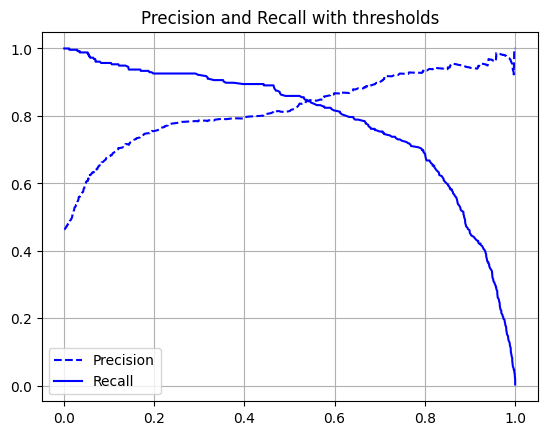

In [ ]:
import matplotlib.pyplot as plt 

# Hàm vẽ biểu đồ sự tương quan giữa precision và recall dựa trên ngưỡng 
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
    plt.plot(thresholds,precisions[:-1],"b--",label="Precision");
    plt.plot(thresholds,recalls[:-1],"b-",label="Recall");
    plt.title('Precision and Recall with thresholds');
    plt.legend();
    plt.grid();
    plt.show();

plot_precision_recall_vs_threshold(precisions,recalls,thresholds);

In [23]:
#Tạo hàm để tính precision và recall khi thay đổi ngưỡng
def thresholds_change(thresholds : list):
    for threshold_value in thresholds:
        y_train_pred_threshold=(y_scores>threshold_value);
        print(  f"Threshold : {threshold_value}",
                f"=>Precision : {precision_score(y_train,y_train_pred_threshold)}",
                f"=>Recall : {recall_score(y_train,y_train_pred_threshold)} \n",sep="\n"
            )

threshold_values=[0.5,0.7,0.9]
thresholds_change(threshold_values)
            

Threshold : 0.5
=>Precision : 0.8148148148148148
=>Recall : 0.859375 

Threshold : 0.7
=>Precision : 0.9018691588785047
=>Recall : 0.75390625 

Threshold : 0.9
=>Precision : 0.9426229508196722
=>Recall : 0.44921875 



# NHẬN XÉT SỰ ĐÁNH ĐỔI GIỮA PRECISION VÀ RECALL
=> Từ việc thay đổi ngưỡng ở trên,có thể thấy rằng nếu ngưỡng càng cao thì precision càng tăng (FP giảm) và recall càng giảm (FN tăng).Điều này cũng được chứng minh qua biểu đồ ở trên.

=> Trong bài toán phát hiện nợ xấu thì khi đặt Threshold càng cao (thắt chặt tiêu chuẩn duyệt cho vay) thì sẽ giúp các trường hợp được dự đoán là nợ xấu trở nên đáng tin cậy hơn (Precision cao hơn). Từ đó, doanh nghiệp có thể đưa ra quyết định chuẩn hơn và giảm thiểu rủi ro mất vốn (giảm FP). Tuy nhiên cái giá phải trả là lại vô tình bỏ qua nhiều trường hợp nợ xấu không đạt được đến tiêu chuẩn đó (tăng FN). Đặc biệt nếu đặt ngưỡng rất cao như 0.9 khiến cho precision đạt đến 0.94 nhưng recall lại sụt giảm chỉ còn 0.45 thì sẽ dẫn đến kịch bản: Ngân hàng gần như sẽ không bao giờ xác định sai khách hàng tốt nhưng vô tình lại để lọt hơn một nửa khách hàng có nợ xấu.

=> Điều này đặt ra các chiến lược cụ thể cho ngân hàng: 
1) Nếu ưu tiên chiến lược thận trọng về rủi ro và bảo toàn chất lượng danh mục tín dụng, ngân hàng có thể lựa chọn ngưỡng cao (0.8–0.9) nhằm đảm bảo rằng các trường hợp bị từ chối vay thực sự có xác suất vỡ nợ cao.

2) Nếu mục tiêu là mở rộng thị phần và chấp nhận mức rủi ro trong phạm vi kiểm soát được, ngưỡng 0.5 có thể được xem là một lựa chọn tham khảo để cân bằng giữa precision và recall, đặc biệt trong trường hợp chi phí của FP và FN không quá chênh lệch.

# SO SÁNH BÀI TOÁN DỰ BÁO RỦI RO TÍN DỤNG VÀ BÀI TOÁN NHẬN DẠNG CHỮ SỐ MNIST

Cả bài toán dự báo rủi ro tín dụng và bài toán nhận dạng chữ số MNIST đều thuộc nhóm học có giám sát (supervised learning) và đều là bài toán phân loại (classification). Trong cả hai trường hợp, mô hình học máy được huấn luyện từ dữ liệu có nhãn, sử dụng các đặc trưng đầu vào (features) để dự đoán nhãn đầu ra. Đồng thời, các chỉ số đánh giá như accuracy, precision, recall hay F1-score đều có thể được áp dụng cho cả hai bài toán.

Tuy nhiên, sự khác biệt quan trọng nằm ở mục tiêu thực tiễn và ý nghĩa của sai số dự đoán. Đối với bài toán MNIST, mục tiêu chủ yếu là tối đa hóa độ chính xác của mô hình. Một dự đoán sai (ví dụ nhận nhầm số 3 thành số 5) không gây ra hậu quả thực tế đáng kể, và các loại sai số (false positive và false negative) thường được xem là có mức độ nghiêm trọng tương đương nhau.

Ngược lại, trong bài toán dự báo rủi ro tín dụng, mỗi quyết định dự đoán đều gắn liền với hậu quả tài chính thực tế. Cụ thể, nếu mô hình dự đoán sai một khách hàng tốt thành khách hàng xấu (false positive), ngân hàng sẽ mất đi cơ hội lợi nhuận. Nhưng nếu mô hình dự đoán sai một khách hàng xấu thành khách hàng tốt (false negative), ngân hàng có thể phải đối mặt với nguy cơ mất vốn thực sự. Do đó, hai loại sai số này không đối xứng về chi phí và mức độ rủi ro.

Chính vì sự khác biệt này, bài toán dự báo rủi ro tín dụng được xem là một bài toán phân loại có xét đến chi phí sai số (cost-sensitive classification). Việc lựa chọn ngưỡng phân loại (threshold) không chỉ là vấn đề kỹ thuật, mà còn phản ánh chiến lược kinh doanh và mức độ chấp nhận rủi ro của ngân hàng. Trong khi đó, với bài toán MNIST, ngưỡng phân loại thường không mang ý nghĩa chiến lược mà chủ yếu phục vụ mục tiêu nâng cao độ chính xác dự đoán.

Tóm lại, mặc dù hai bài toán tương đồng về mặt kỹ thuật học máy, nhưng bài toán rủi ro tín dụng có độ phức tạp cao hơn về mặt ứng dụng thực tế, do phải cân bằng giữa hiệu quả mô hình và hậu quả kinh tế của các quyết định dự đoán.

SyntaxError: invalid syntax (246308154.py, line 3)